# NB10 — Analysis & Paper Assets

Aggregates every upstream `outputs/` artifact into paper-ready **tables, figures, and LaTeX**.
Each section is guarded — if an upstream notebook hasn't run yet it is **skipped cleanly** (never
emits NaN rows or broken figures). Re-run after any upstream notebook to refresh.

Outputs → `outputs/paper/` (CSV + `.tex` per table, PNG per figure).


In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
PAPER="../outputs/paper"; os.makedirs(PAPER, exist_ok=True)
def exists(p): return os.path.isfile(p)
def load_json(p): return json.load(open(p)) if exists(p) else None
def load_csv(p):  return pd.read_csv(p) if exists(p) else None
def save_table(df, name):
    df.to_csv(f"{PAPER}/{name}.csv", index=False)
    try:
        with open(f"{PAPER}/{name}.tex","w") as f: f.write(df.to_latex(index=False, escape=True))
    except Exception as e: print("  (latex skip:", e, ")")
    print(f"  ✅ {name}: CSV + tex")
print("paper dir:", PAPER)

paper dir: ../outputs/paper


In [2]:
# ── Table 1: Main results (baselines + per-model + ensemble), 20% test ──────
rows=[]
bl=load_csv("../outputs/baselines/baseline_results.csv")
if bl is not None:
    for _,r in bl.iterrows():
        rows.append({"System":r["model"],"Type":"baseline","Macro-F1":r["macro_f1"],
                     "Weighted-F1":r["weighted_f1"],"Accuracy":r["accuracy"],"MCC":r["mcc"],"AUROC":r.get("auroc",np.nan)})
pm=load_csv("../outputs/models_main/per_run_summary.csv")
if pm is not None:
    for mk,g in pm.groupby("model"):
        rows.append({"System":mk,"Type":"transformer (mean±std)",
                     "Macro-F1":f"{g['macro_f1'].mean():.4f}±{g['macro_f1'].std():.4f}",
                     "Weighted-F1":f"{g['weighted_f1'].mean():.4f}±{g['weighted_f1'].std():.4f}",
                     "Accuracy":f"{g['accuracy'].mean():.4f}","MCC":f"{g['mcc'].mean():.4f}","AUROC":f"{g['auroc'].mean():.4f}"})
ens=load_json("../outputs/ensemble/ensemble_test_metrics.json")
if ens is not None:
    rows.append({"System":f"Ensemble ({ens.get('system','-')})","Type":"ours","Macro-F1":ens["macro_f1"],
                 "Weighted-F1":ens["weighted_f1"],"Accuracy":ens["accuracy"],"MCC":ens["mcc"],"AUROC":ens["macro_auroc"]})
alt=load_json("../outputs/altmethod/benchmark/metrics.json")
if alt is not None:
    rows.append({"System":"BanglishBERT full-stack (alt, seed-ens)","Type":"ours-alt","Macro-F1":alt["macro_f1"],
                 "Weighted-F1":alt["weighted_f1"],"Accuracy":alt["accuracy"],"MCC":alt["mcc"],"AUROC":alt["macro_auroc"]})
if rows:
    t1=pd.DataFrame(rows)
    print("TABLE 1 — Main results (20% test)"); print(t1.to_string(index=False)); save_table(t1,"table1_main_results")
else:
    print("⏭ Table 1 skipped (run NB04/NB05/NB06 first)")

TABLE 1 — Main results (20% test)
                                 System                   Type      Macro-F1   Weighted-F1 Accuracy     MCC   AUROC
                     TFIDF(word)+LogReg               baseline        0.5025        0.6142   0.6025  0.4273   0.846
             TFIDF(word+char)+LinearSVM               baseline        0.7674        0.7889   0.7933  0.6788  0.9418
                                 BiLSTM               baseline         0.685        0.7106   0.7065  0.5663  0.9052
                             banglabert transformer (mean±std) 0.8136±0.0027 0.8198±0.0018   0.8204  0.7583  0.9605
                           banglishbert transformer (mean±std) 0.8049±0.0047 0.8175±0.0044   0.8193  0.7221  0.9561
                                  muril transformer (mean±std) 0.8068±0.0015 0.8197±0.0020   0.8206  0.7258  0.9515
                                   xlmr transformer (mean±std) 0.8034±0.0018 0.8159±0.0015   0.8162  0.7193  0.9514
                 Ensemble (weighted+LA

TABLE 2 — Per-class F1 (ensemble, 20% test)
    Class     F1
religious 0.9031
     none 0.8771
   sexual 0.8238
   threat 0.7689
  abusive 0.7397
  ✅ table2_per_class: CSV + tex


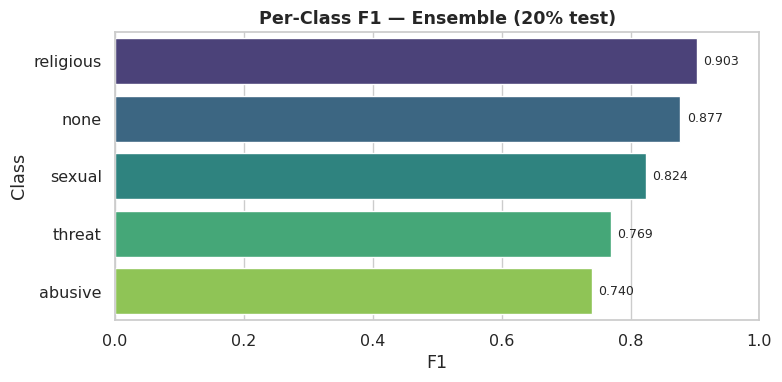

In [3]:
# ── Table 2 + Fig: Per-class F1 of the ensemble ─────────────────────────────
ens=load_json("../outputs/ensemble/ensemble_test_metrics.json")
if ens is not None and ens.get("per_class_f1"):
    pcf=ens["per_class_f1"]
    t2=pd.DataFrame({"Class":list(pcf.keys()),"F1":list(pcf.values())}).sort_values("F1",ascending=False)
    print("TABLE 2 — Per-class F1 (ensemble, 20% test)"); print(t2.to_string(index=False)); save_table(t2,"table2_per_class")
    fig,ax=plt.subplots(figsize=(8,4))
    sns.barplot(data=t2,y="Class",x="F1",ax=ax,palette="viridis")
    for i,v in enumerate(t2["F1"]): ax.text(v+0.01,i,f"{v:.3f}",va="center",fontsize=9)
    ax.set_xlim(0,1); ax.set_title("Per-Class F1 — Ensemble (20% test)",fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{PAPER}/fig_per_class_f1.png",dpi=150,bbox_inches="tight"); plt.show()
else:
    print("⏭ Table 2 skipped (run NB06 first)")

TABLE 3 — Component ablation
       config  macro_f1  weighted_f1  accuracy    mcc
CE+FGM (ours)    0.8071       0.8194    0.8207 0.7249
    +focal+CW    0.8086       0.8202    0.8220 0.7266
     +sampler    0.7997       0.8135    0.8142 0.7164
         +MSD    0.8108       0.8219    0.8228 0.7285
       +RDrop    0.8122       0.8229    0.8242 0.7302
         +EMA    0.8114       0.8235    0.8251 0.7312
   ALL (full)    0.8043       0.8159    0.8162 0.7192
  ✅ table3_component_ablation: CSV + tex


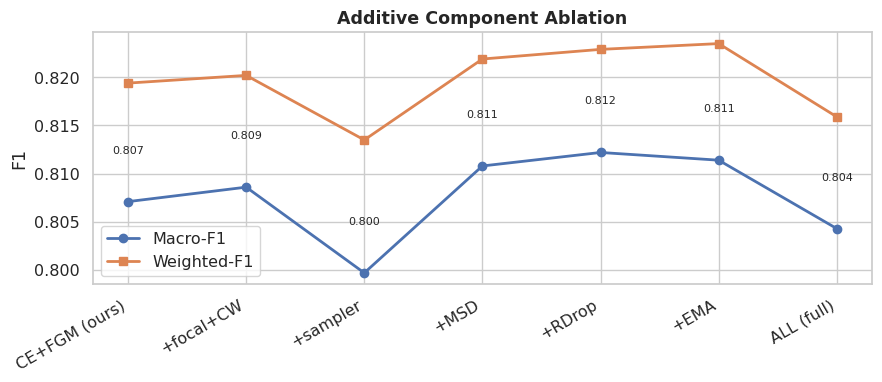

In [4]:
# ── Table 3 + Fig: Component ablation ───────────────────────────────────────
ca=load_csv("../outputs/ablation/component_ablation.csv")
if ca is not None:
    t3=ca[["config","macro_f1","weighted_f1","accuracy","mcc"]].copy()
    print("TABLE 3 — Component ablation"); print(t3.to_string(index=False)); save_table(t3,"table3_component_ablation")
    fig,ax=plt.subplots(figsize=(9,4))
    ax.plot(t3["config"],t3["macro_f1"],marker="o",lw=2,label="Macro-F1")
    ax.plot(t3["config"],t3["weighted_f1"],marker="s",lw=2,label="Weighted-F1")
    for x,y in zip(range(len(t3)),t3["macro_f1"]): ax.text(x,y+0.005,f"{y:.3f}",ha="center",fontsize=8)
    ax.set_title("Additive Component Ablation",fontweight="bold"); ax.set_ylabel("F1"); ax.legend()
    plt.xticks(rotation=30,ha="right"); plt.tight_layout()
    plt.savefig(f"{PAPER}/fig_ablation.png",dpi=150,bbox_inches="tight"); plt.show()
else:
    print("⏭ Table 3 skipped (run NB08 first)")

In [5]:
# ── Table 4: Taxonomy ablation (5 vs 9 class) ───────────────────────────────
ta=load_csv("../outputs/ablation/taxonomy_ablation.csv")
if ta is not None:
    t4=ta[["config","macro_f1","weighted_f1","accuracy","mcc"]].copy()
    print("TABLE 4 — Taxonomy ablation (5 vs 9 class)"); print(t4.to_string(index=False)); save_table(t4,"table4_taxonomy")
else:
    print("⏭ Table 4 skipped (run NB08 first)")

TABLE 4 — Taxonomy ablation (5 vs 9 class)
       config  macro_f1  weighted_f1  accuracy    mcc
5-class(ours)    0.8071       0.8194    0.8207 0.7249
9-class(ours)    0.6096       0.8018    0.8076 0.7079
  ✅ table4_taxonomy: CSV + tex


TABLE 5 — Robustness (source/script held-out)
                         config         held_out  n_test  macro_f1  weighted_f1  accuracy    mcc
          script_holdout_bangla           bangla   56989    0.1631       0.2617    0.3898 0.1088
       script_holdout_romanized        romanized   37334    0.2165       0.6051    0.6425 0.0845
           source_holdout_banth            banth   37334    0.2165       0.6051    0.6425 0.0845
          source_holdout_bd_shs           bd_shs    5029    0.4549       0.5657    0.5383 0.3943
  source_holdout_facebook_44001   facebook_44001   43078    0.5828       0.6256    0.6344 0.5186
source_holdout_multilabel_12557 multilabel_12557    8882    0.5579       0.5640    0.5907 0.4444
  ✅ table5_robustness: CSV + tex


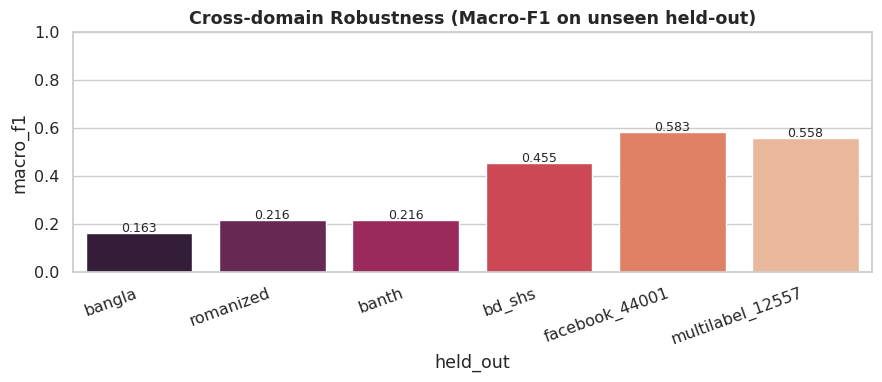

In [6]:
# ── Table 5 + Fig: Robustness (held-outs) ───────────────────────────────────
rb=load_csv("../outputs/altmethod/robustness_summary.csv")
if rb is None: rb=load_csv("../outputs/robustness/robustness_summary.csv")
if rb is not None:
    t5=rb[["config","held_out","n_test","macro_f1","weighted_f1","accuracy","mcc"]].copy()
    print("TABLE 5 — Robustness (source/script held-out)"); print(t5.to_string(index=False)); save_table(t5,"table5_robustness")
    fig,ax=plt.subplots(figsize=(9,4))
    sns.barplot(data=t5,x="held_out",y="macro_f1",ax=ax,palette="rocket")
    for i,v in enumerate(t5["macro_f1"]): ax.text(i,v+0.005,f"{v:.3f}",ha="center",fontsize=9)
    ax.set_title("Cross-domain Robustness (Macro-F1 on unseen held-out)",fontweight="bold"); ax.set_ylim(0,1)
    plt.xticks(rotation=20,ha="right"); plt.tight_layout()
    plt.savefig(f"{PAPER}/fig_robustness.png",dpi=150,bbox_inches="tight"); plt.show()
else:
    print("⏭ Table 5 skipped (run NB07 first)")

TABLE 6 — vs Base paper (facebook 15% test)
    Class  Base paper  Ours (CE+FGM ens)  Ours-alt (full-stack)
Not Bully      0.9151             0.8891                 0.8813
Religious      0.9374             0.9302                 0.9366
   Sexual      0.8845             0.8720                 0.8711
   Threat      0.7579             0.8292                 0.8337
    Troll      0.8446             0.8192                 0.8122
 MACRO-F1      0.8923             0.8679                 0.8670
  ✅ table6_basepaper: CSV + tex


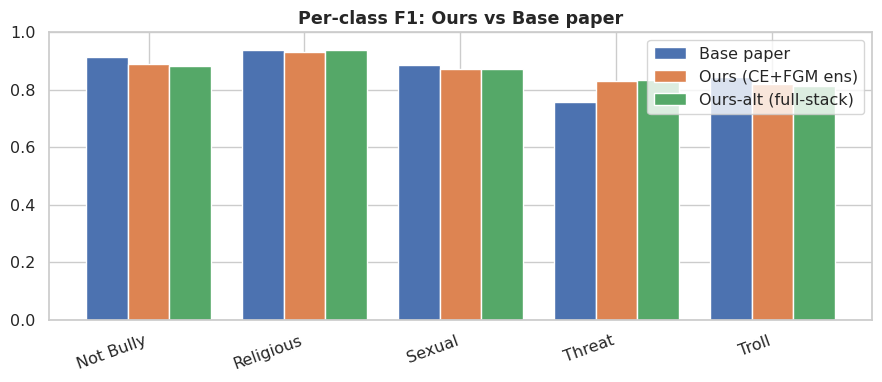

In [7]:
# ── Table 6 + Fig: Base-paper head-to-head (main CE+FGM and/or alt full-stack) ──
cmp=load_json("../outputs/basepaper/comparison.json")          # main method (NB09)
alt=load_json("../outputs/altmethod/basepaper_comparison.json") # alternate (NB07b)
if cmp is not None or alt is not None:
    base = cmp["base_paper"] if cmp else alt["base_paper"]
    cls_list = list((cmp["ours"]["per_class_f1"] if cmp else alt["ours_alt"]["per_class_f1"]).keys())
    rows=[]
    for c in cls_list:
        row={"Class":c,"Base paper":base["per_class"].get(c,np.nan)}
        if cmp is not None: row["Ours (CE+FGM ens)"]=cmp["ours"]["per_class_f1"].get(c,np.nan)
        if alt is not None: row["Ours-alt (full-stack)"]=alt["ours_alt"]["per_class_f1"].get(c,np.nan)
        rows.append(row)
    mrow={"Class":"MACRO-F1","Base paper":base["macro_f1"]}
    if cmp is not None: mrow["Ours (CE+FGM ens)"]=cmp["ours"]["macro_f1"]
    if alt is not None: mrow["Ours-alt (full-stack)"]=alt["ours_alt"]["macro_f1"]
    rows.append(mrow)
    t6=pd.DataFrame(rows)
    print("TABLE 6 — vs Base paper (facebook 15% test)"); print(t6.to_string(index=False)); save_table(t6,"table6_basepaper")
    pc=t6[t6["Class"]!="MACRO-F1"]; ours_cols=[c for c in t6.columns if c.startswith("Ours")]
    x=np.arange(len(pc)); series=["Base paper"]+ours_cols; w=0.8/len(series); fig,ax=plt.subplots(figsize=(9,4))
    for j,s in enumerate(series): ax.bar(x+(j-(len(series)-1)/2)*w, pc[s], w, label=s)
    ax.set_xticks(x); ax.set_xticklabels(pc["Class"],rotation=20,ha="right"); ax.set_ylim(0,1)
    ax.set_title("Per-class F1: Ours vs Base paper",fontweight="bold"); ax.legend()
    plt.tight_layout(); plt.savefig(f"{PAPER}/fig_basepaper.png",dpi=150,bbox_inches="tight"); plt.show()
else:
    print("⏭ Table 6 skipped (run NB09 and/or NB07b first)")

In [8]:
# ── Manifest of generated assets ────────────────────────────────────────────
assets=sorted(os.listdir(PAPER))
print(f"\n📦 {len(assets)} assets in {PAPER}:")
for a in assets: print("   ", a)


📦 16 assets in ../outputs/paper:
    fig_ablation.png
    fig_basepaper.png
    fig_per_class_f1.png
    fig_robustness.png
    table1_main_results.csv
    table1_main_results.tex
    table2_per_class.csv
    table2_per_class.tex
    table3_component_ablation.csv
    table3_component_ablation.tex
    table4_taxonomy.csv
    table4_taxonomy.tex
    table5_robustness.csv
    table5_robustness.tex
    table6_basepaper.csv
    table6_basepaper.tex
